In [1]:
import matplotlib.pyplot as plt 
import pandas as pd 

data_iso_40 = pd.read_csv("results_iso.csv")
data_iso_120 = pd.read_csv("results_iso_120.csv")
data_aniso_40 = pd.read_csv("results_aniso_40_200.csv")
data_aniso_40_200 = pd.read_csv("results_aniso_40_200_width.csv")
data_iso_120_width = pd.read_csv("results_iso_120_width.csv")

data_aniso_40_200

,Mesh,Pressure,Area_start,Area_end,Width_start,Width_end,Length_start,Length_end,Volume_1_start,Volume_2_start,Volume_1_end,Volume_2_end,Pore_width_start,Pore_width_end,Pore_height_start,Pore_height_end,Min_diameter_start,Min_diameter_end
0,1_2,0.01,40.56,47.62,4.90748,4.90748,14.314,14.314,3463.16,3596.71,3775.53,3897.55,4.9,5.8,11.0,11.0,4.9,5.8
1,1_2,0.11,40.56,58.85,4.90748,4.90748,14.314,14.314,3463.16,3596.71,3994.14,4148.22,4.9,6.8,11.0,11.7,4.9,6.8
2,1_2,0.21,40.56,64.25,4.90748,4.90748,14.314,14.314,3463.16,3596.71,4069.94,4250.61,4.9,7.2,11.0,12.0,4.9,7.2
3,1_2,0.31,40.56,68.40,4.90748,4.90748,14.314,14.314,3463.16,3596.71,4132.12,4337.66,4.9,7.4,11.0,12.2,4.9,7.4
4,1_2,0.41,40.56,71.97,4.90748,4.90748,14.314,14.314,3463.16,3596.71,4194.46,4408.93,4.9,7.7,11.0,12.4,4.9,7.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,3_7,0.51,21.96,41.90,0.00000,0.00000,0.000,0.000,3581.47,4073.96,4026.79,4847.10,3.0,5.3,10.4,10.8,3.0,5.3
176,3_7,0.61,21.96,43.54,0.00000,0.00000,0.000,0.000,3581.47,4073.96,4075.30,4916.35,3.0,5.4,10.4,10.9,3.0,5.4
177,3_7,0.71,21.96,45.11,0.00000,0.00000,0.000,0.000,3581.47,4073.96,4123.51,4983.98,3.0,5.6,10.4,11.0,3.0,5.6
178,3_7,0.81,21.96,46.48,0.00000,0.00000,0.000,0.000,3581.47,4073.96,4171.78,5050.74,3.0,5.7,10.4,11.1,3.0,5.7


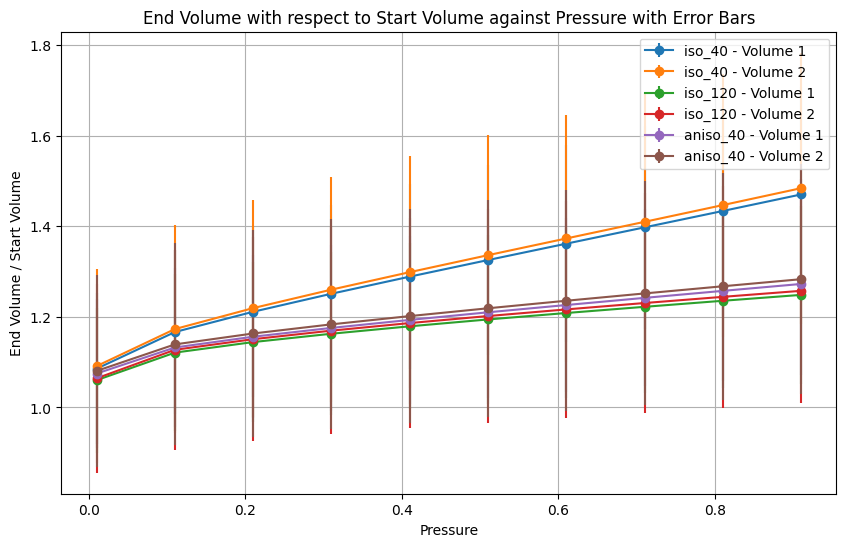

In [7]:
## For each dataset, plot the change in volume with respect to the initial volume, against the pressure. Include the error bars.

import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
data1 = data_iso_40
data2 = data_iso_120
data3 = data_aniso_40

dataset1 = "iso_40"
dataset2 = "iso_120"
dataset3 = "aniso_40"

def process_data(data):
    # Group by Pressure and calculate mean and standard deviation
    grouped = data.groupby('Pressure').agg({
        ' Volume_1_start': ['mean', 'std'],
        ' Volume_2_start': ['mean', 'std'],
        ' Volume_1_end': ['mean', 'std'],
        ' Volume_2_end': ['mean', 'std']
    }).reset_index()

    # Flatten the MultiIndex columns
    grouped.columns = ['Pressure', 'Volume_1_start_mean', 'Volume_1_start_std', 'Volume_2_start_mean', 'Volume_2_start_std', 'Volume_1_end_mean', 'Volume_1_end_std', 'Volume_2_end_mean', 'Volume_2_end_std']

    # Calculate the ratio of end volume to start volume
    grouped['Volume_1_ratio'] = grouped['Volume_1_end_mean'] / grouped['Volume_1_start_mean']
    grouped['Volume_2_ratio'] = grouped['Volume_2_end_mean'] / grouped['Volume_2_start_mean']

    # Calculate the error bars
    grouped['Volume_1_ratio_err'] = grouped['Volume_1_ratio'] * ((grouped['Volume_1_end_std'] / grouped['Volume_1_end_mean'])**2 + (grouped['Volume_1_start_std'] / grouped['Volume_1_start_mean'])**2)**0.5
    grouped['Volume_2_ratio_err'] = grouped['Volume_2_ratio'] * ((grouped['Volume_2_end_std'] / grouped['Volume_2_end_mean'])**2 + (grouped['Volume_2_start_std'] / grouped['Volume_2_start_mean'])**2)**0.5

    return grouped

# Process each dataset
grouped1 = process_data(data1)
grouped2 = process_data(data2)
grouped3 = process_data(data3)

# Plot the data with error bars
plt.figure(figsize=(10, 6))

plt.errorbar(grouped1['Pressure'], grouped1['Volume_1_ratio'], yerr=grouped1['Volume_1_ratio_err'], label= dataset1 + ' - Volume 1', fmt='-o')
plt.errorbar(grouped1['Pressure'], grouped1['Volume_2_ratio'], yerr=grouped1['Volume_2_ratio_err'], label= dataset1 + ' - Volume 2', fmt='-o')

plt.errorbar(grouped2['Pressure'], grouped2['Volume_1_ratio'], yerr=grouped2['Volume_1_ratio_err'], label= dataset2 + ' - Volume 1', fmt='-o')
plt.errorbar(grouped2['Pressure'], grouped2['Volume_2_ratio'], yerr=grouped2['Volume_2_ratio_err'], label= dataset2 + ' - Volume 2', fmt='-o')

plt.errorbar(grouped3['Pressure'], grouped3['Volume_1_ratio'], yerr=grouped3['Volume_1_ratio_err'], label= dataset3 + ' - Volume 1', fmt='-o')
plt.errorbar(grouped3['Pressure'], grouped3['Volume_2_ratio'], yerr=grouped3['Volume_2_ratio_err'], label= dataset3 + ' - Volume 2', fmt='-o')

plt.xlabel('Pressure')
plt.ylabel('End Volume / Start Volume')
plt.title('End Volume with respect to Start Volume against Pressure with Error Bars')
plt.legend()
plt.grid(True)
plt.show()



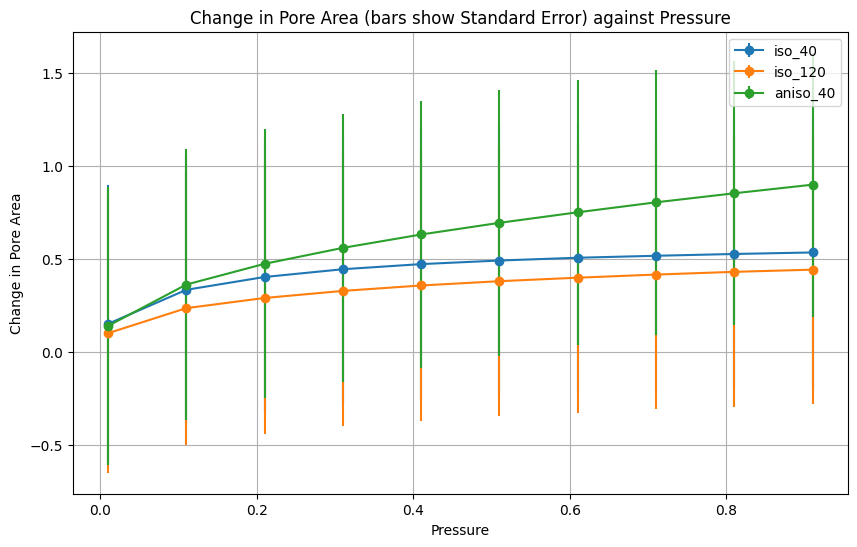

In [8]:
def process_data(data):
    # Group by Pressure and calculate mean and standard deviation
    grouped = data.groupby('Pressure').agg({
        'Area_start': ['mean', 'std'],
        'Area_end': ['mean', 'std']
    }).reset_index()

    # Flatten the MultiIndex columns
    grouped.columns = ['Pressure', 'Area_start_mean', 'Area_start_std', 'Area_end_mean', 'Area_end_std']

    # Calculate the change in pore area
    grouped['Area_change'] = (grouped['Area_end_mean'] - grouped['Area_start_mean']) / grouped['Area_start_mean']

    # Calculate the error bars for the relative change
    grouped['Area_change_err'] = ((grouped['Area_end_std'] / grouped['Area_end_mean'])**2 + 
                                  (grouped['Area_start_std'] / grouped['Area_start_mean'])**2)**0.5

    return grouped

# Process each dataset
grouped1 = process_data(data1)
grouped2 = process_data(data2)
grouped3 = process_data(data3)

# Plot the data with error bars
plt.figure(figsize=(10, 6))

plt.errorbar(grouped1['Pressure'], grouped1['Area_change'], yerr=grouped1['Area_change_err'], label=dataset1, fmt='-o')
plt.errorbar(grouped2['Pressure'], grouped2['Area_change'], yerr=grouped2['Area_change_err'], label=dataset2, fmt='-o')
plt.errorbar(grouped3['Pressure'], grouped3['Area_change'], yerr=grouped3['Area_change_err'], label=dataset3, fmt='-o')

plt.xlabel('Pressure')
plt.ylabel('Change in Pore Area')
plt.title('Change in Pore Area (bars show Standard Error) against Pressure')
plt.legend()
plt.grid(True)
plt.show()


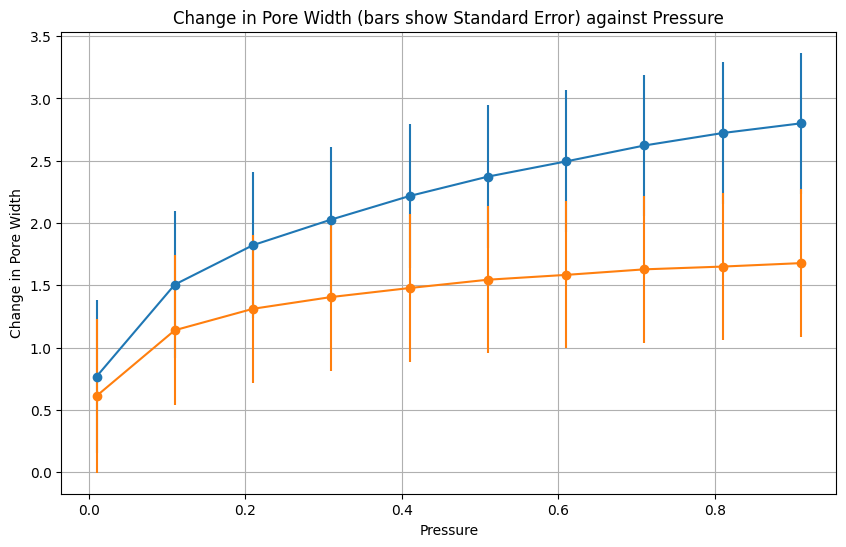

In [9]:
## For the data_aniso_40_200_width data set, plot the change in pore width

def process_data(data):
    # Group by Pressure and calculate mean and standard deviation
    grouped = data.groupby('Pressure').agg({
        'Pore_width_start': ['mean', 'std'],
        'Pore_width_end': ['mean', 'std']
    }).reset_index()

    # Flatten the MultiIndex columns
    grouped.columns = ['Pressure', 'Width_start_mean', 'Width_start_std', 'Width_end_mean', 'Width_end_std']

    # Calculate the change in pore width
    grouped['Width_change'] = (grouped['Width_end_mean'] - grouped['Width_start_mean'])

    # Calculate the error bars for the relative change
    grouped['Width_change_err'] = ((grouped['Width_end_std'] / grouped['Width_end_mean'])**2 + 
                                  (grouped['Width_start_std'] / grouped['Width_start_mean'])**2)**0.5

    return grouped

# Process the dataset
grouped = process_data(data_aniso_40_200)
grouped2 = process_data(data_iso_120_width)

# Plot the data with error bars
plt.figure(figsize=(10, 6))

plt.errorbar(grouped['Pressure'], grouped['Width_change'], yerr=grouped['Width_change_err'], fmt='-o')
plt.errorbar(grouped2['Pressure'], grouped2['Width_change'], yerr=grouped2['Width_change_err'], fmt='-o')

plt.xlabel('Pressure')

plt.ylabel('Change in Pore Width')

plt.title('Change in Pore Width (bars show Standard Error) against Pressure')

plt.grid(True)

plt.show()


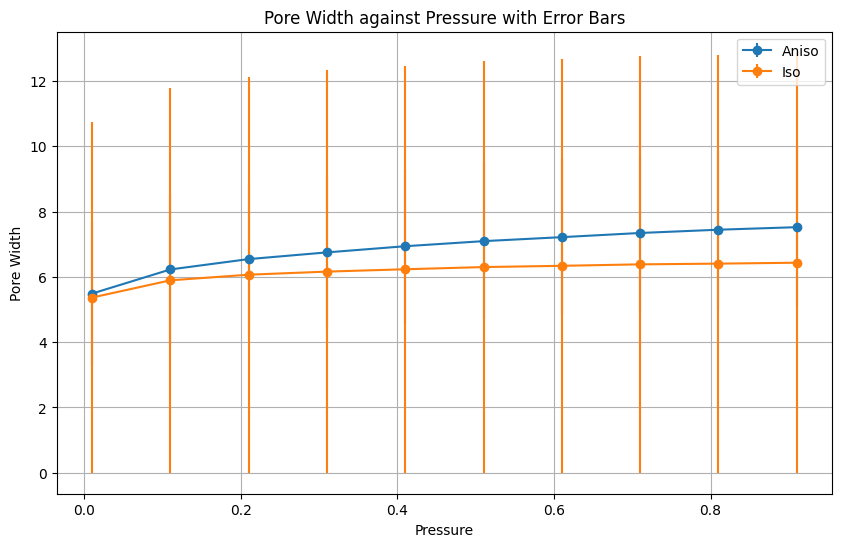

In [10]:
## Plot the absolute pore width against the pressure for the data_aniso_40_200_width data set

def process_data(data):
    # Group by Pressure and calculate mean and standard deviation
    grouped = data.groupby('Pressure').agg({
        'Pore_width_start': ['mean', 'std'],
        'Pore_width_end': ['mean', 'std']
    }).reset_index()

    # Flatten the MultiIndex columns
    grouped.columns = ['Pressure', 'Width_start_mean', 'Width_start_std', 'Width_end_mean', 'Width_end_std']

    return grouped

# Process the dataset
grouped = process_data(data_aniso_40_200)
grouped2 = process_data(data_iso_120_width)

# Plot the data with error bars
plt.figure(figsize=(10, 6))

plt.errorbar(grouped['Pressure'], grouped['Width_end_mean'], yerr=grouped['Width_end_std'], label='Aniso', fmt='-o')
plt.errorbar(grouped2['Pressure'], grouped2['Width_end_mean'], yerr=grouped2['Width_end_mean'], label='Iso', fmt='-o')

plt.xlabel('Pressure')
plt.ylabel('Pore Width')
plt.title('Pore Width against Pressure with Error Bars')
plt.legend()
plt.grid(True)
plt.show()

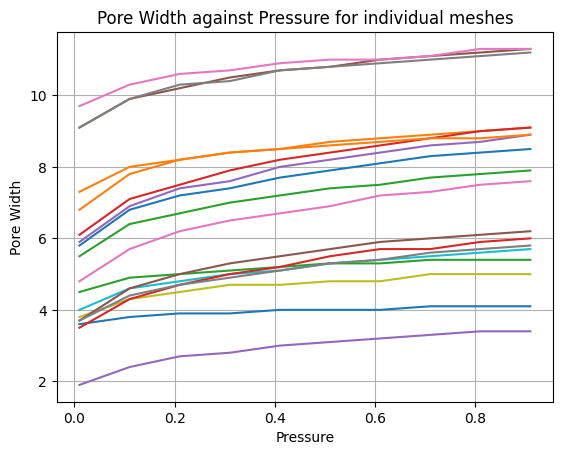

In [27]:
## Plot pore width against pressure for all individual meshes

meshes = data_aniso_40_200["Mesh"].unique()

for mesh in meshes:
    data = data_aniso_40_200[data_aniso_40_200["Mesh"] == mesh]
    plt.plot(data["Pressure"], data["Pore_width_end"], label=mesh)

plt.xlabel('Pressure')
plt.ylabel('Pore Width')
plt.title('Pore Width against Pressure for individual meshes')
#plt.legend()
plt.grid(True)
plt.show()





In [39]:
data_aniso_40_200_filtered["Mesh"].unique()

array(['1_2', '1_3', '1_4', '1_5', '1_6', '1_8', '2_1', '2_3', '2_6a',
       '2_7a', '3_1', '3_2', '3_4', '3_6', '3_7'], dtype=object)

In [ ]:
## Metrics for onion meshes: calculated by hand (width, height)

mesh_1_2 = [[15.8, 9.3],[16.6, 11.1]]
mesh_1_3 = [[16.1, 10.8],[16.2, 10.1]]
mesh_1_4 = [[15.6, 11.2],[13.8, 11.6]]
mesh_1_5 = [[18.1, 12.5], [17.4, 11.5]]
mesh_1_6 = [[16.3, 11.6],[15.2, 12.4]]
mesh_1_8 = [[14.3, 11.5], [15.5, 11.3]]
mesh_2_1 = [[13.4, 10.2], [13.2, 9.3]]
mesh_2_3 = [[13.6, 7.1],[15.8, 7.9]] ## Issues?
##mesh_2_4 ## Issue
mesh_2_6a = [[17.0, 10.8],[16.9, 10.2]]
mesh_2_6b = [[16.2, 12.6],[15.6, 10.8]] ## Odd cross section
mesh_2_7a = [[13.9, 10.5], [13.7, 11.6]]
mesh_3_1 = [[14.6, 10.9], [14.6, 11.1]]
mesh_3_2 = [[17.3, 12.8],[17.3, 12.3]]
mesh_3_3 = [[17.9, 13.0],[17.2, 11.2]]



meshes = [mesh_1_2, mesh_1_3, mesh_1_4, mesh_1_5, mesh_1_6, mesh_1_8, mesh_2_1, mesh_2_6a, mesh_2_6b, mesh_2_7a, mesh_3_1]

In [97]:
metrics = []

for mesh in meshes:
    metrics.append(mesh[0][0] / mesh[0][1])
    print(mesh[0][0] / mesh[0][1])
    metrics.append(mesh[1][0] / mesh[1][1])
    print(mesh[1][0] / mesh[1][1])

sum(metrics) / len(metrics)

1.6989247311827957
1.4954954954954958
1.4907407407407407
1.603960396039604
1.392857142857143
1.1896551724137931
1.4480000000000002
1.5130434782608695
1.4051724137931036
1.225806451612903
1.2434782608695654
1.3716814159292035
1.3137254901960786
1.4193548387096773
1.574074074074074
1.656862745098039
1.2857142857142856
1.4444444444444444
1.3238095238095238
1.1810344827586208
1.3394495412844036
1.3153153153153154


1.4060272927545308

In [98]:
metrics[0]

1.6989247311827957

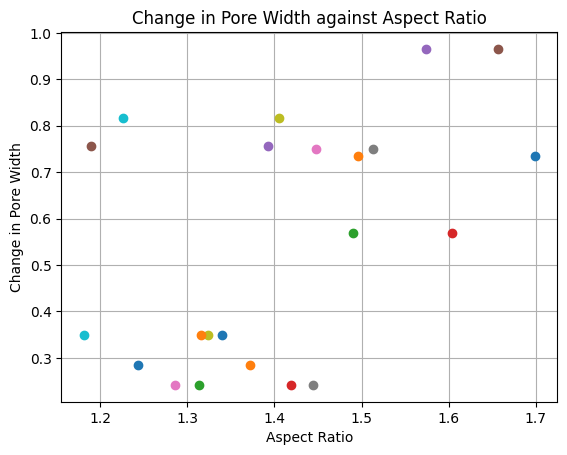

In [99]:
## Plot the aspect ratio against the change in pore width

data_set_meshes = ["1_2","1_3","1_4","1_5","1_6","1_8","2_1","2_6a","2_6b","2_7a","3_1"]
i = 0
for mesh in data_set_meshes:
    data = data_aniso_40_200[(data_aniso_40_200["Mesh"] == mesh) & (data_aniso_40_200["Pressure"] > 0.9)]
    metric1 = metrics[i]
    metric2 = metrics[i+1]
    plt.plot(metric1, (data["Pore_width_end"] - data["Pore_width_start"]) / data["Pore_width_start"], 'o', label=mesh)
    plt.plot(metric2, (data["Pore_width_end"] - data["Pore_width_start"]) / data["Pore_width_start"], 'o', label=mesh)
    i += 2

plt.xlabel('Aspect Ratio')
plt.ylabel('Change in Pore Width')
plt.title('Change in Pore Width against Aspect Ratio')
#plt.legend()
plt.grid(True)
plt.show()

### Flattening a Cylinder to Achieve a 1.44:1 Aspect Ratio

If you want to change the cross-section aspect ratio of a cylinder from **1:1 (a perfect circle)** to **1.44:1 (width:height)** by flattening it along the **z-axis**, you need to scale it in the **z-direction** by a factor \( s \).

#### Step-by-step calculation:

1. **Define the original cross-section:**
   - If the cylinder originally has a circular cross-section with radius \( r \), then both width (x-direction) and height (z-direction) are equal to \( 2r \).

2. **After flattening (scaling in z):**
   - Width remains **\( 2r \)**.
   - Height scales to **\( 2sr \)**, where \( s \) is the flattening factor in the z-direction.

3. **Set up the aspect ratio equation:**
   \[
   \frac{\text{width}}{\text{height}} = \frac{2r}{2sr} = \frac{1}{s} = 1.44
   \]

4. **Solve for \( s \):**
   \[
   s = \frac{1}{1.44} \approx 0.694
   \]

#### Conclusion:
To achieve a width:height ratio of **1.44:1**, you need to **scale (flatten) the cylinder in the z-direction by a factor of approximately 0.694**. This means the new height of the cross-section will be about **69.4% of the original height**.


In [80]:
data

,Mesh,Pressure,Area_start,Area_end,Width_start,Width_end,Length_start,Length_end,Volume_1_start,Volume_2_start,Volume_1_end,Volume_2_end,Pore_width_start,Pore_width_end,Pore_height_start,Pore_height_end,Min_diameter_start,Min_diameter_end,Pore_height_width_ratio
79,2_3,0.91,73.41,118.89,0.0,0.0,0.0,0.0,3178.74,3569.28,3868.21,4562.36,8.0,11.2,13.0,14.2,8.0,11.2,1.625
